In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [21]:
df = pd.read_excel(r"C:\Users\silpa\Downloads\ABC Company.xlsx")
print("Shape of dataset:", df.shape)
display(df.head())

Shape of dataset: (458, 9)


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [22]:
df.shape

(458, 9)

In [23]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight', 'College', 'Salary']


In [24]:
print("\nData types:")
print(df.dtypes)


Data types:
Name         object
Team         object
Number        int64
Position     object
Age           int64
Height       object
Weight        int64
College      object
Salary      float64
dtype: object


In [25]:
print("\nMissing values:")
display(df.isnull().sum())


Missing values:


Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [26]:
print("\nSummary statistics:")
display(df.describe(include="all"))


Summary statistics:


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
count,458,458,458.000000,458,458.000000,458,458.000000,374,4.470000e+02
unique,458,30,NaN,5,NaN,18,NaN,118,NaN
top,Avery Bradley,New Orleans Pelicans,NaN,SG,NaN,2023-09-06 00:00:00,NaN,Kentucky,NaN
freq,1,19,NaN,102,NaN,59,NaN,22,NaN
mean,NaN,NaN,17.713974,NaN,26.934498,NaN,221.543668,NaN,4.833970e+06
std,NaN,NaN,15.966837,NaN,4.400128,NaN,26.343200,NaN,5.226620e+06
min,NaN,NaN,0.000000,NaN,19.000000,NaN,161.000000,NaN,3.088800e+04
25%,NaN,NaN,5.000000,NaN,24.000000,NaN,200.000000,NaN,1.025210e+06
50%,NaN,NaN,13.000000,NaN,26.000000,NaN,220.000000,NaN,2.836186e+06
75%,NaN,NaN,25.000000,NaN,30.000000,NaN,240.000000,NaN,6.500000e+06


In [27]:
np.random.seed(42)

In [28]:
df["Height"] = np.random.randint(
    150,
    181,
    size=len(df)
)

In [29]:
print("Minimum height:", df["Height"].min())
print("Maximum height:", df["Height"].max())

Minimum height: 150
Maximum height: 180


In [30]:
display(df[["Name", "Height"]].head(10))

,Name,Height
0,Avery Bradley,156
1,Jae Crowder,169
2,John Holland,178
3,R.J. Hunter,164
4,Jonas Jerebko,160
5,Amir Johnson,157
6,Jordan Mickey,178
7,Kelly Olynyk,170
8,Terry Rozier,156
9,Marcus Smart,175


In [31]:
np.random.randint(150, 181)

161

In [32]:
team_counts = df["Team"].value_counts().sort_values(ascending=False)

In [33]:
team_distribution = pd.DataFrame({
    "Team": team_counts.index,
    "Employee_Count": team_counts.values
})

In [34]:
team_distribution["Percentage"] = (
    team_distribution["Employee_Count"] / len(df) * 100
)

In [35]:
display(team_distribution)

,Team,Employee_Count,Percentage
0,New Orleans Pelicans,19,4.148472
1,Memphis Grizzlies,18,3.930131
2,Utah Jazz,16,3.493450
3,New York Knicks,16,3.493450
4,Milwaukee Bucks,16,3.493450
5,Detroit Pistons,15,3.275109
6,Dallas Mavericks,15,3.275109
7,Philadelphia 76ers,15,3.275109
8,Toronto Raptors,15,3.275109
9,Golden State Warriors,15,3.275109


In [36]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<BarContainer object of 30 artists>

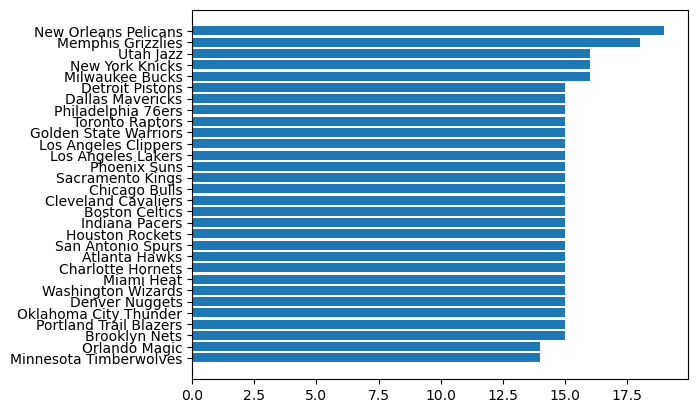

In [37]:
plt.barh(
    team_distribution["Team"][::-1],
    team_distribution["Employee_Count"][::-1]
)

Text(0, 0.5, 'Team')

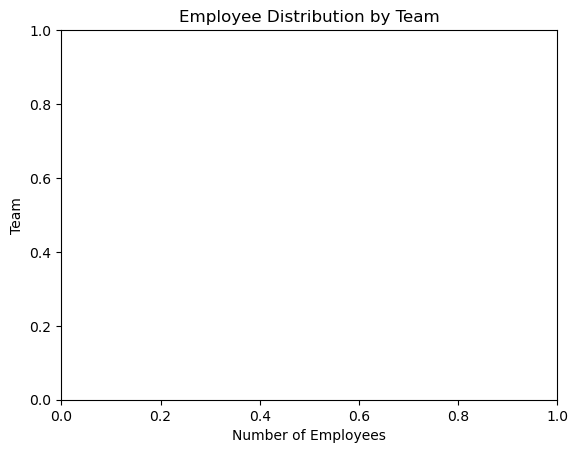

In [38]:
plt.title("Employee Distribution by Team")
plt.xlabel("Number of Employees")
plt.ylabel("Team")

In [39]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [40]:
position_counts = df["Position"].value_counts()

In [41]:
position_distribution = pd.DataFrame({
    "Position": position_counts.index,
    "Employee_Count": position_counts.values
})

In [42]:
position_distribution["Percentage"] = (
    position_distribution["Employee_Count"] / len(df) * 100
)

In [43]:
display(position_distribution)

,Position,Employee_Count,Percentage
0,SG,102,22.270742
1,PF,100,21.834061
2,PG,92,20.087336
3,SF,85,18.558952
4,C,79,17.248908


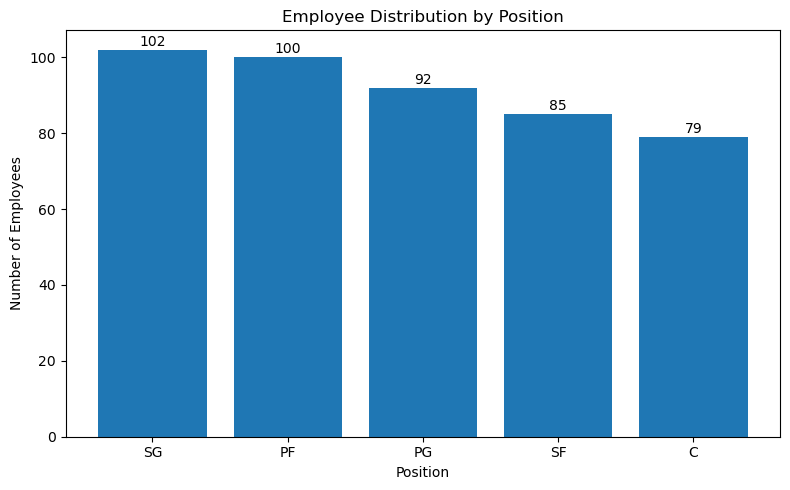

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    position_distribution["Position"],
    position_distribution["Employee_Count"]
)

for i, v in enumerate(position_distribution["Employee_Count"]):
    plt.text(i, v + 1, str(v), ha="center")

plt.title("Employee Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [45]:
age_bins = [18, 20, 25, 30, 35, 40]

In [46]:
age_labels = [
    "19-20",
    "21-25",
    "26-30",
    "31-35",
    "36-40"
]

In [47]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [48]:
age_distribution = df["Age_Group"].value_counts().reindex(age_labels)

In [49]:
age_distribution_df = pd.DataFrame({
    "Age_Group": age_distribution.index.astype(str),
    "Employee_Count": age_distribution.values
})

In [50]:
age_distribution_df["Percentage"] = (
    age_distribution_df["Employee_Count"] / len(df) * 100
)

In [51]:
display(age_distribution_df)

,Age_Group,Employee_Count,Percentage
0,19-20,21,4.585153
1,21-25,179,39.082969
2,26-30,167,36.462882
3,31-35,68,14.847162
4,36-40,23,5.021834


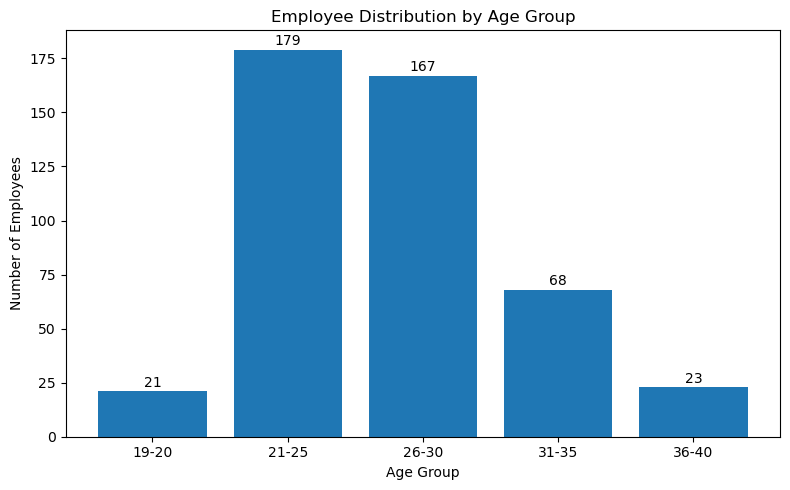

In [52]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_distribution_df["Age_Group"],
    age_distribution_df["Employee_Count"]
)

for i, v in enumerate(age_distribution_df["Employee_Count"]):
    plt.text(i, v + 2, str(v), ha="center")

plt.title("Employee Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [54]:
team_salary = (
    df.groupby("Team")["Salary"]
      .sum()
      .sort_values(ascending=False)
)

In [55]:
display(team_salary.head(10).to_frame("Total Salary"))

,Total Salary
Team,
Cleveland Cavaliers,106988689.0
Los Angeles Clippers,94854640.0
Oklahoma City Thunder,93765298.0
Golden State Warriors,88868997.0
Chicago Bulls,86783378.0
San Antonio Spurs,84442733.0
New Orleans Pelicans,82750774.0
Miami Heat,82515673.0
Charlotte Hornets,78340920.0


In [56]:
position_salary = (
    df.groupby("Position")["Salary"]
      .sum()
      .sort_values(ascending=False)
)

In [57]:
display(position_salary.to_frame("Total Salary"))

,Total Salary
Position,
C,466377332.0
PG,446848971.0
PF,442560850.0
SF,408020976.0
SG,396976258.0


In [58]:
team_position_salary = (
    df.groupby(["Team", "Position"])["Salary"]
      .sum()
      .reset_index()
      .sort_values("Salary", ascending=False)
)

In [59]:
display(team_position_salary.head(10))

,Team,Position,Salary
67,Los Angeles Lakers,SF,31866445.0
75,Miami Heat,PF,31538671.0
53,Houston Rockets,SG,28122883.0
116,Phoenix Suns,PG,28002998.0
37,Denver Nuggets,SF,27982771.0
25,Cleveland Cavaliers,PF,27882029.0
93,New Orleans Pelicans,SG,27489643.0
124,Sacramento Kings,C,26950230.0
102,Oklahoma City Thunder,SF,25798862.0
61,Los Angeles Clippers,PG,25527217.0


In [60]:
top_combo = team_position_salary.head(10).copy()

In [61]:
top_combo["Label"] = (
    top_combo["Team"] + " - " + top_combo["Position"]
)

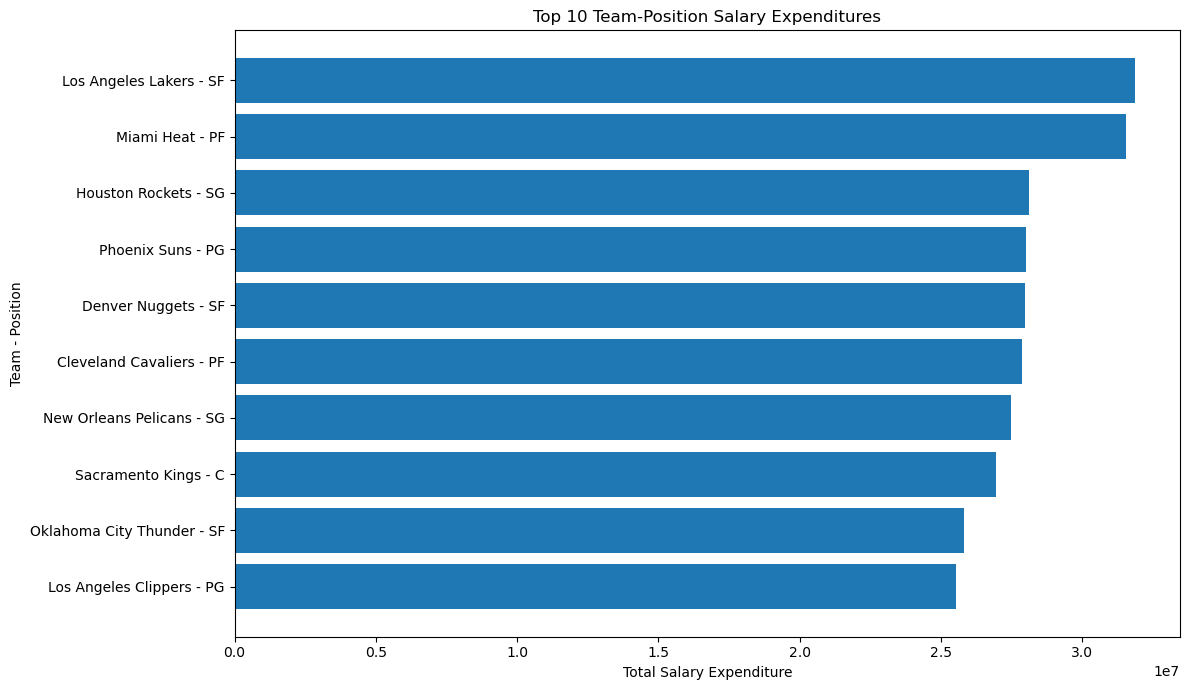

In [62]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_combo["Label"][::-1],
    top_combo["Salary"][::-1]
)

plt.title("Top 10 Team-Position Salary Expenditures")
plt.xlabel("Total Salary Expenditure")
plt.ylabel("Team - Position")

plt.tight_layout()
plt.show()

In [63]:
corr_data = df[["Age", "Salary"]].dropna()

In [64]:
correlation = corr_data["Age"].corr(
    corr_data["Salary"]
)

In [65]:
print("Pearson correlation:", correlation)

Pearson correlation: 0.21400941226570985


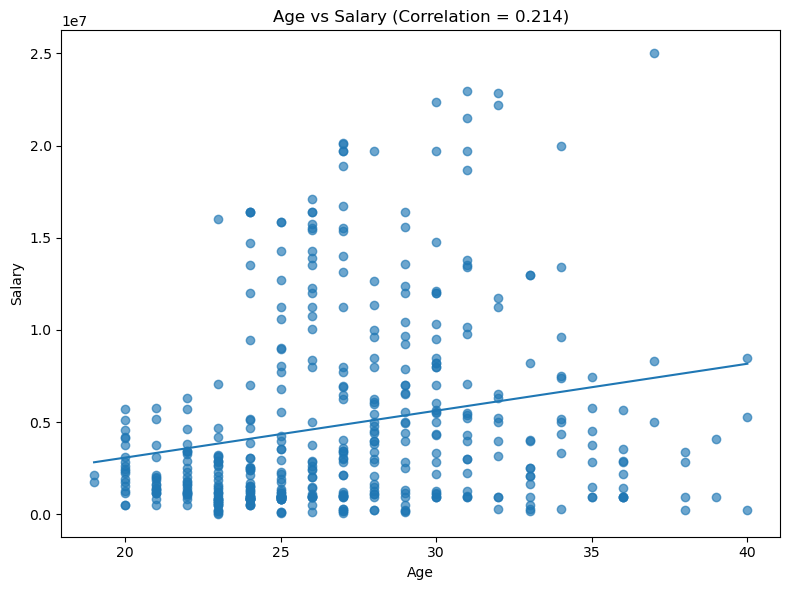

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    corr_data["Age"],
    corr_data["Salary"],
    alpha=0.65
)

x = corr_data["Age"].to_numpy()
y = corr_data["Salary"].to_numpy()

m, b = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 100)

plt.plot(xx, m * xx + b)

plt.title(
    f"Age vs Salary (Correlation = {correlation:.3f})"
)

plt.xlabel("Age")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()